/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_45487/2639368852.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set1', n_clusters)


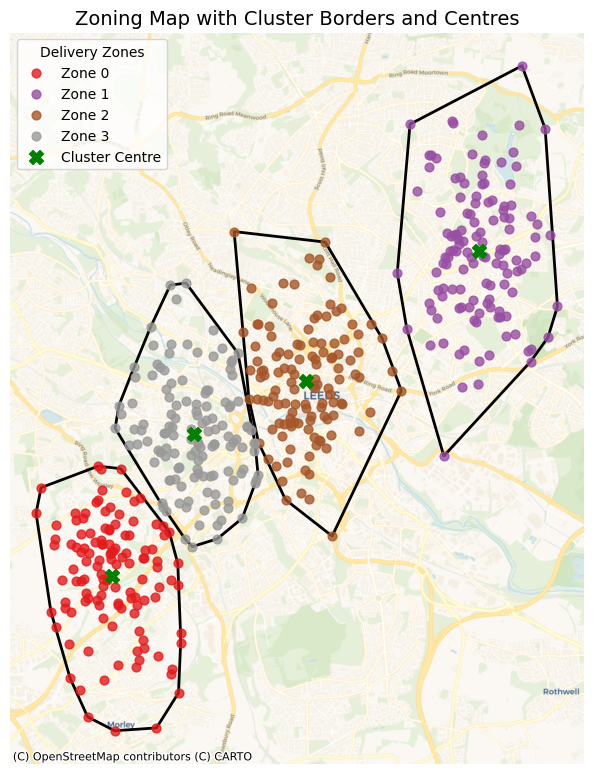

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, MultiPoint
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import contextily as ctx
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- Generate synthetic delivery data ---
n_clusters = 4
n_samples = 500
centers = [
    [53.8008, -1.5491],
    [53.8200, -1.5000],
    [53.7700, -1.6000],
    [53.7900, -1.5800],
]
X, _ = make_blobs(n_samples=n_samples, centers=centers, cluster_std=0.01, random_state=42)
df = pd.DataFrame(X, columns=['latitude', 'longitude'])
df['demand_volume'] = np.random.poisson(lam=n_clusters, size=n_samples)

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']), crs='EPSG:4326')
gdf = gdf.to_crs(epsg=3857)  # Web Mercator for mapping with contextily

# Apply KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
gdf['zone'] = kmeans.fit_predict(df[['latitude', 'longitude']])

# Create convex hulls for each zone
hulls = []
for cluster_id in gdf['zone'].unique():
    points = gdf[gdf['zone'] == cluster_id]
    if len(points) >= 3:
        hull = MultiPoint(points.geometry.values).convex_hull
        hulls.append({'geometry': hull, 'zone': cluster_id})
hulls_gdf = gpd.GeoDataFrame(hulls, crs=gdf.crs)

# Get cluster centres and convert to GeoDataFrame
centres_latlon = kmeans.cluster_centers_
centres_df = pd.DataFrame(centres_latlon, columns=['latitude', 'longitude'])
centres_gdf = gpd.GeoDataFrame(
    centres_df, 
    geometry=gpd.points_from_xy(centres_df['longitude'], centres_df['latitude']), 
    crs='EPSG:4326'
).to_crs(epsg=3857)

# Set up custom colour map
cmap = cm.get_cmap('Set1', n_clusters)
norm = mcolors.Normalize(vmin=0, vmax=n_clusters - 1)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# Plot convex hulls
hulls_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2, linestyle='-')

# Plot delivery points with colour-matched edges
for cluster in range(n_clusters):
    cluster_data = gdf[gdf['zone'] == cluster]
    colour = cmap(cluster)
    ax.scatter(
        cluster_data.geometry.x,
        cluster_data.geometry.y,
        s=40,
        c=[colour],
        edgecolors=[colour],
        label=f'Zone {cluster}',
        alpha=0.8,
        linewidth=1
    )

# Plot cluster centres as green dots
centres_gdf.plot(ax=ax, marker='X', color='green', markersize=100, label='Cluster Centre')

# Add basemap and final touches
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)
ax.set_title("Zoning Map with Cluster Borders and Centres", fontsize=14)
ax.legend(title='Delivery Zones')
ax.set_axis_off()
ax.set_aspect
plt.tight_layout()
plt.savefig("leeds_zoning_map_with_cluster_centres.png", dpi=300)
plt.show()

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_45487/1957436064.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', len(unique_labels))


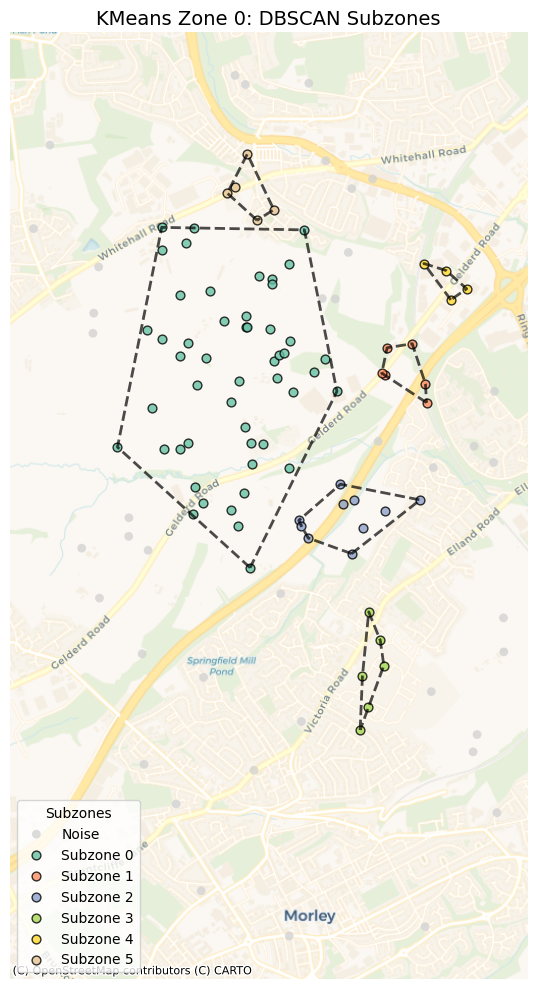

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_45487/1957436064.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', len(unique_labels))


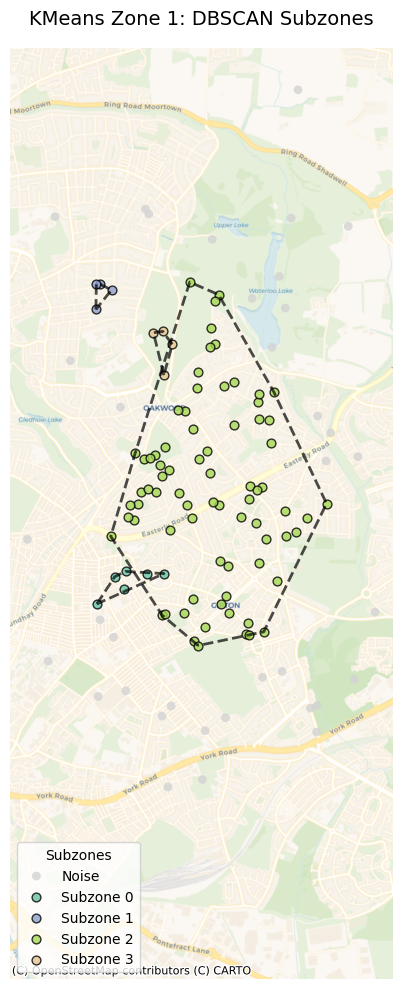

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_45487/1957436064.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', len(unique_labels))


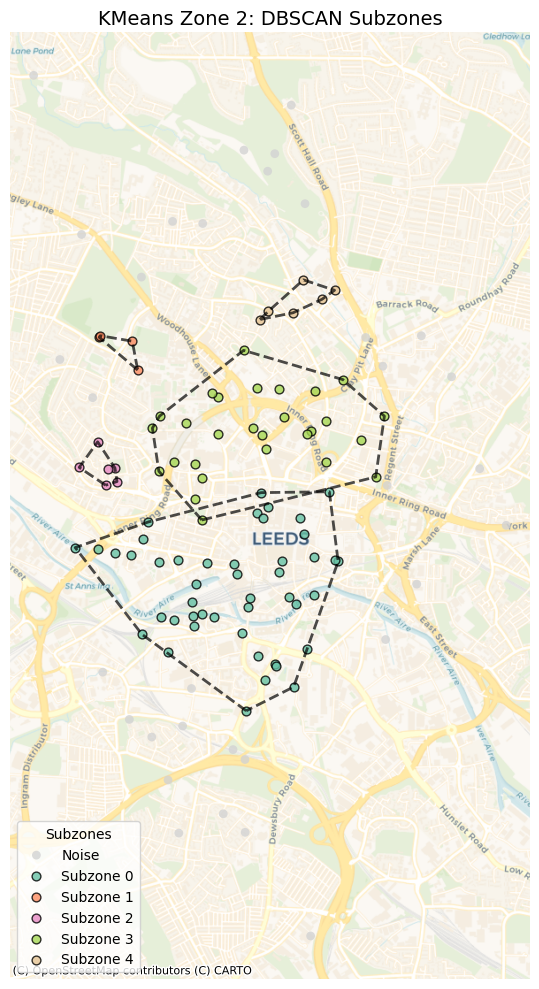

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_45487/1957436064.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sub_cmap = cm.get_cmap('Set2', len(unique_labels))


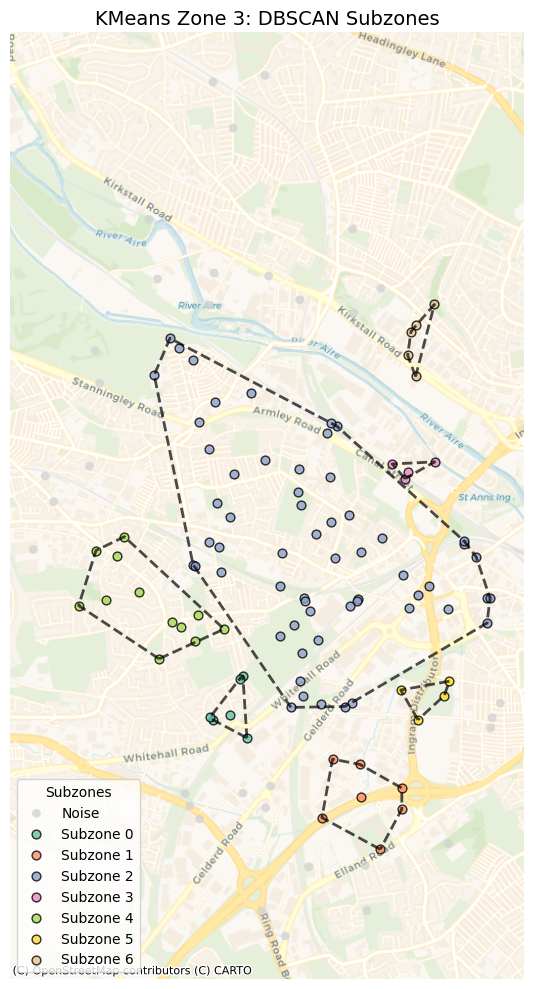

In [28]:
from sklearn.cluster import DBSCAN
from shapely.geometry import MultiPoint
import matplotlib.patches as patches

# DBSCAN parameters
db_eps = 450  # metres
db_min_samples = 4

for zone_id in range(n_clusters):
    # Subset the data for this KMeans zone
    sub_gdf = gdf[gdf['zone'] == zone_id].copy()

    # Extract coordinates (Web Mercator)
    coords = np.vstack([sub_gdf.geometry.x, sub_gdf.geometry.y]).T

    # Apply DBSCAN
    db = DBSCAN(eps=db_eps, min_samples=db_min_samples)
    sub_gdf['subzone'] = db.fit_predict(coords)

    # Colour map for subzones
    unique_labels = sorted(sub_gdf['subzone'].unique())
    sub_cmap = cm.get_cmap('Set2', len(unique_labels))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 10))

    for label in unique_labels:
        cluster_data = sub_gdf[sub_gdf['subzone'] == label]
        colour = 'lightgrey' if label == -1 else sub_cmap(label)

        # Plot points
        ax.scatter(
            cluster_data.geometry.x,
            cluster_data.geometry.y,
            s=40,
            c=[colour],
            edgecolors='k' if label != -1 else 'none',
            label=f'Subzone {label}' if label != -1 else 'Noise',
            alpha=0.8
        )

        # Add convex hull ring if not noise
        if label != -1 and len(cluster_data) >= 3:
            hull = MultiPoint(cluster_data.geometry.values).convex_hull
            if hull.geom_type == 'Polygon':
                xs, ys = hull.exterior.xy
                ax.plot(xs, ys, color='black', linewidth=2, linestyle='--', alpha=0.7)

    # Basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)

    # Title and formatting
    ax.set_title(f"KMeans Zone {zone_id}: DBSCAN Subzones", fontsize=14)
    ax.legend(title="Subzones", loc='lower left')
    ax.set_axis_off()
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()